# Calibration vs. science frames at four pointings

Pick the first and last pointings (by chronological time) in each of the
two datasets that have all four (LO, noise_on) combinations available, and
compare the noise-on and noise-off spectra at each LO.

Layout: 4 rows x 2 columns. Rows: streaming start, streaming end, main start,
main end. Columns: LO1, LO2. Each panel overlays mean noise-on and
noise-off spectra at that pointing/LO. Uses `corr11` (Stokes pol-1) for both
datasets so the y-axis is comparable.

Scanning streaming...
  1638 pointings
  start: (l=86, b=+4), first dump t=1776333476
  end: (l=239, b=-3), first dump t=1777003454
Scanning main...
  0 pointings


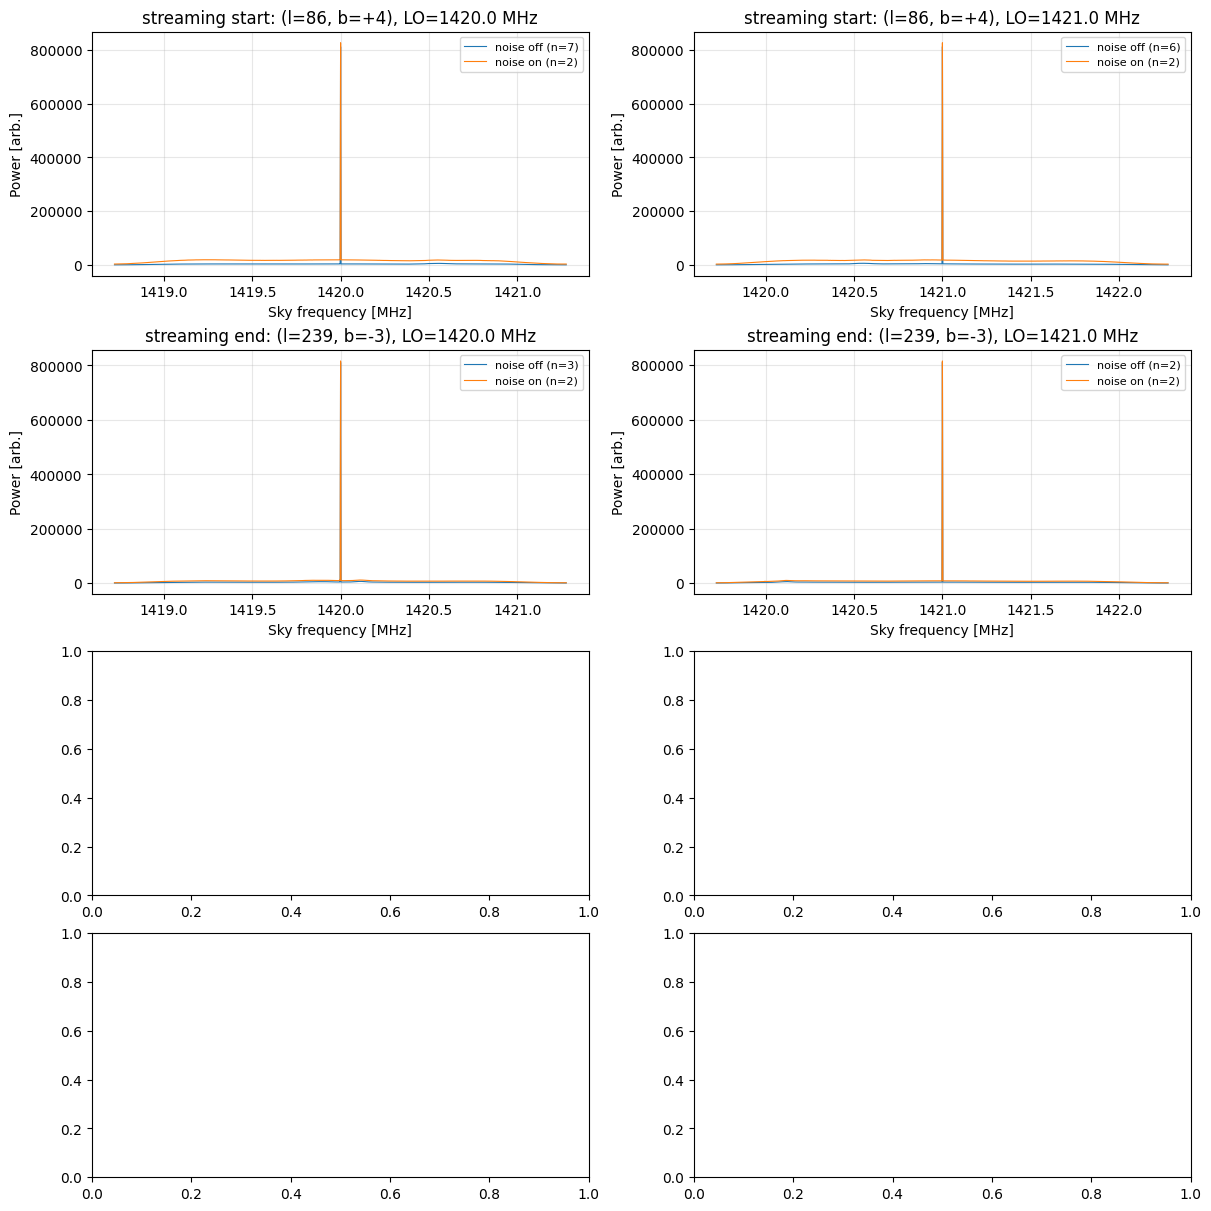

In [1]:
import sys
sys.path.insert(0, '..')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NFFT = 1024

DATASETS = {
    'streaming': {
        'dir': Path('../../../data/lab04/streaming'),
        'sample_rate_hz': 2.56e6,
        'lo1': 1420.0,
        'lo2': 1421.0,
    },
    'main': {
        'dir': Path('../../../data/lab04/main'),
        'sample_rate_hz': 3.2e6,
        'lo1': 1419.86,
        'lo2': 1421.14,
    },
}


def collect_dataset(cfg):
    """Return {(l, b): {(lo_mhz, noise_on): [(time, spec), ...]}}."""
    cells = {}
    for session_dir in sorted(cfg['dir'].glob('session_*')):
        for cell_dir in sorted(session_dir.iterdir()):
            if not cell_dir.is_dir():
                continue
            name = cell_dir.name
            if not (name.startswith('obs_') or name.startswith('cal_')):
                continue
            try:
                _, l_str, b_str = name.split('_', 2)
                l, b = int(l_str), int(b_str)
            except ValueError:
                continue
            for p in sorted(cell_dir.glob('*.npz')):
                with np.load(p, allow_pickle=True) as f:
                    lo = float(f['lo_freq_mhz'])
                    on = bool(f['noise_on'])
                    t = float(f['time'])
                    spec = np.fft.fftshift(f['corr11'].astype(float))
                cells.setdefault((l, b), {}).setdefault((lo, on), []).append((t, spec))
    return cells


def pick_first_last(cells, lo1, lo2):
    """First and last cells (by earliest dump time) with all 4 (lo, on) combos."""
    needed = [(lo1, True), (lo1, False), (lo2, True), (lo2, False)]
    cands = []
    for (l, b), specs in cells.items():
        if not all(k in specs and specs[k] for k in needed):
            continue
        t_min = min(t for k in needed for (t, _) in specs[k])
        cands.append((t_min, l, b, specs))
    if len(cands) < 2:
        return None
    cands.sort()
    return cands[0], cands[-1]


selected = []
for name, cfg in DATASETS.items():
    print(f'Scanning {name}...')
    cells = collect_dataset(cfg)
    print(f'  {len(cells)} pointings')
    pair = pick_first_last(cells, cfg['lo1'], cfg['lo2'])
    if pair is None:
        print(f'  WARNING: not enough cells with all 4 (LO, noise) combos')
        continue
    first, last = pair
    for tag, (t_min, l, b, specs) in [('start', first), ('end', last)]:
        selected.append((name, tag, l, b, specs))
        print(f'  {tag}: (l={l}, b={b:+d}), first dump t={t_min:.0f}')

f_bb_cache = {
    name: np.fft.fftshift(np.fft.fftfreq(NFFT, 1.0 / cfg['sample_rate_hz'])) / 1e6
    for name, cfg in DATASETS.items()
}

fig, axes = plt.subplots(4, 2, figsize=(12, 12), constrained_layout=True)
for row, (name, tag, l, b, specs) in enumerate(selected):
    cfg = DATASETS[name]
    f_bb = f_bb_cache[name]
    for col, lo in enumerate([cfg['lo1'], cfg['lo2']]):
        ax = axes[row, col]
        on_list = [s for (_, s) in specs[(lo, True)]]
        off_list = [s for (_, s) in specs[(lo, False)]]
        on_mean = np.nanmean(on_list, axis=0)
        off_mean = np.nanmean(off_list, axis=0)
        f_sky = lo + f_bb
        ax.plot(f_sky, off_mean, label=f'noise off (n={len(off_list)})',
                color='C0', lw=0.8)
        ax.plot(f_sky, on_mean, label=f'noise on (n={len(on_list)})',
                color='C1', lw=0.8)
        ax.set_xlabel('Sky frequency [MHz]')
        ax.set_ylabel('Power [arb.]')
        ax.set_title(f'{name} {tag}: (l={l}, b={b:+d}), LO={lo} MHz')
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)

plt.show()